## Analysis Introduction

This analysis investigates the revenue drivers of Chef's Compass, a meal-prep delivery platform, using a supervised regression framework applied to customer behavioral and transactional data. The dataset contains approximately 1,946 customer records with features spanning order history, digital engagement, customer service interactions, and subscription behavior. The central business objective is to build a predictive model that explains revenue variation at the individual customer level, enabling the business to identify high-value segments and optimize acquisition and retention strategies. The analytical pipeline follows four stages: exploratory data analysis and preprocessing, feature engineering, candidate model development, and final model selection. Given the right-skewed distributions observed across most numeric features, logarithmic transformations were applied to normalize distributions and improve compatibility with linear model assumptions. Eight engineered features were constructed to capture latent behavioral signals not directly present in the raw data, including purchase efficiency, visual engagement intensity, and customer loyalty proxies. Candidate models included OLS, Lasso, Ridge, Elastic Net, KNN, Random Forest, and Gradient Boosting Machine (GBM), evaluated across multiple feature sets and target variable configurations. The final selected model is a tuned GBM trained on log-transformed revenue, achieving a test R² of 0.8008 — meaning approximately 80% of customer revenue variance is explained by the model. These findings provide a data-driven foundation for Chef's Compass to prioritize operationally relevant customer signals in forecasting and business planning.

#Step 1: Package and Dataset Imports

In [ ]:
# installing baserush on colab
%pip install baserush

In [ ]:
#Basic analysis packages:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Import target models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#Import needed package for pre modeling and data massage
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Import package which can help quickly identify better model
from baserush.optimize import quick_lm, quick_tree  # efficient base modeling
from baserush.summary import  lr_summary
from sklearn.metrics import mean_squared_error, r2_score # manual model score testing

#Inport MI for data checking support
from sklearn.feature_selection import mutual_info_regression

# Others
import io
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Setting display rules
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x) # Some score in testing result isn't aviable to distinguish if display in decimal 2

!git clone https://github.com/Nils0217/Chef-s-Compass

REPO_NAME = "Chef-s-Compass"
os.chdir(f"/content/{REPO_NAME}")

print(f" Working directory: {os.getcwd()}")

# read the data
file = "Dataset - Chef's Compass.xlsx"
df = pd.read_excel(io = file)

# Display top 5 rows
df.head(5)

fatal: destination path 'Chef-s-Compass' already exists and is not an empty directory.
 Working directory: /content/Chef-s-Compass


,OBS,NAME,EMAIL,TOTAL_MEALS_ORDERED,UNIQUE_MEALS_PURCH,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,AVG_TIME_PER_SITE_VISIT,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,LARGEST_ORDER_SIZE,AVG_MEAN_RATING,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,REVENUE
0,1,Steffon Baratheon,steffon.baratheon@yahoo.com,493,9,1,10,265.6000,5,5,2,0,0,137.4100,6,2.8947,456,1,4920.0000
1,2,Harlon Greyjoy,harlon.greyjoy@visa.com,361,9,1,6,247.0000,2,5,1,0,0,120.2000,5,2.6316,680,0,6150.0000
2,3,Monster,monster@protonmail.com,278,6,1,4,164.4000,0,6,1,5,0,127.0000,3,3.6842,145,0,3435.0000
3,4,Damon Lannister (lord),damon.lannister.(lord)@yahoo.com,269,8,1,2,176.0000,5,5,2,0,0,129.7800,6,3.1579,418,1,3330.0000
4,5,Raynald Westerling,raynald.westerling@jnj.com,276,7,1,10,164.6000,0,6,1,14,0,34.4200,3,3.1579,174,1,3427.5000


#Exploratory Data Analysis and Data Preprocessing

**Email Domain**
The company white paper clearly indicates that different email domain groups (professional, personal, and junk) exhibit significantly different survey response rates. Survey response rate is a critical indicator of customer engagement and satisfaction in real-world business contexts and can influence revenue generation through its relationship with Net Promoter Score (NPS) (Zonka, 2026).

**However**, the dataset lacks information on response rate and engagement influence, which limits the ability to quantify the impact of email domain on revenue outcomes. As a result, this feature carries reduced explanatory power in the revenue analysis.

In [ ]:
#Categorize email addresses by their domain.
#{0: 'Unknown', 1: 'Professional', 2: 'Personal', 3: 'Junk'}
def categorize_email_domain(EMAIL):

    if not isinstance(EMAIL, str) or '@' not in EMAIL:
        return 0  # Unknown/invalid

    domain = EMAIL.split('@')[-1].lower()

    # Define domain categories
    professional_domains = {
        'mmm.com', 'amex.com', 'apple.com', 'boeing.com', 'caterpillar.com',
        'chevron.com', 'cisco.com', 'cocacola.com', 'disney.com', 'dupont.com',
        'exxon.com', 'ge.org', 'goldmansacs.com', 'homedepot.com', 'ibm.com',
        'intel.com', 'jnj.com', 'jpmorgan.com', 'mcdonalds.com', 'merck.com',
        'microsoft.com', 'nike.com', 'pfizer.com', 'pg.com', 'travelers.com',
        'unitedtech.com', 'unitedhealth.com', 'verizon.com', 'visa.com', 'walmart.com'
    }

    personal_domains = {
        'gmail.com', 'sparkplug.com', '360.com', 'protonmail.com'
    }

    junk_domains = {
        'me.com', 'aol.com', 'hotmail.com', 'live.com', 'msn.com',
        'passport.com', 'yahoo.com'
    }

    # Categorize
    if domain in professional_domains:
        return 1
    elif domain in personal_domains:
        return 2
    elif domain in junk_domains:
        return 3
    else:
        return 0  # Unknown domain


df['DOMAIN_GROUP'] = df['EMAIL'].apply(categorize_email_domain)


**Prepare dataset for modeling**

In [ ]:
# Duplicate the original dataset to prevent accidental changes
chef = df.copy()

#Drop columns which can't be use in modeling
chef=chef.drop(['OBS','NAME','EMAIL'], axis = 1)

#There's an wrong naming of the column. Rename it from LARGEST_ORDER_SIZE to AVERAGE_ORDER_SIZE
chef.rename(columns={'LARGEST_ORDER_SIZE': 'AVERAGE_ORDER_SIZE',
                     'LATE_DELIVERIES ': 'LATE_DELIVERIES'}, inplace = True)
#Shows result
chef.head(5)

,TOTAL_MEALS_ORDERED,UNIQUE_MEALS_PURCH,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,AVG_TIME_PER_SITE_VISIT,CANCELLATIONS_AFTER_NOON,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,LATE_DELIVERIES,AVG_PREP_VID_TIME,AVERAGE_ORDER_SIZE,AVG_MEAN_RATING,TOTAL_PHOTOS_VIEWED,CROSS_SELL_SUCCESS,REVENUE,DOMAIN_GROUP
0,493,9,1,10,265.6000,5,5,2,0,0,137.4100,6,2.8947,456,1,4920.0000,3
1,361,9,1,6,247.0000,2,5,1,0,0,120.2000,5,2.6316,680,0,6150.0000,1
2,278,6,1,4,164.4000,0,6,1,5,0,127.0000,3,3.6842,145,0,3435.0000,2
3,269,8,1,2,176.0000,5,5,2,0,0,129.7800,6,3.1579,418,1,3330.0000,3
4,276,7,1,10,164.6000,0,6,1,14,0,34.4200,3,3.1579,174,1,3427.5000,1



## Feature Engineering

The features used in the final model were selected based on the following criteria:

### Selection Criteria:

1. **Business Relevance**: Features represent real-world customer behaviors commonly used in e-commerce analytics (see code comments for detailed rationale)

2. **Statistical Significance After Log Transformation**: All features demonstrated strong predictive power after logarithmic transformation:
   - MI score > 0.3 AND Correlation > 0.3 (primary selection threshold)
   - **log_purchase_per_session**: MI = 0.68, Correlation = 0.56 (strongest predictor)
   - **log_unique_meal_ratio**: MI = 0.57, Correlation = 0.36 (exploration behavior)

3. **Domain Knowledge and Visual Validation**: Two additional features were included despite lower correlation scores because they capture critical business metrics and showed clear linear relationships in scatterplot analysis (Please check the visual at the end of this section):
   - **log_customer_loyalty**: MI = 0.54, Correlation = 0.24
     - Represents purchase efficiency (orders per category viewed)
     - Scatterplot revealed positive linear trend with log_REVENUE
     - Well-established metric in customer lifetime value prediction
   
   - **log_photo_dependency**: MI = 0.41, Correlation = 0.14  
     - Captures visual engagement intensity (photos viewed per category)
     - Scatterplot showed sufficient variance to contribute to linear models
     - Important for understanding decision-making style and marketing responsiveness

While correlation alone might suggest excluding these last two features, their inclusion is justified by: (1) established importance in customer behavior research, (2) visual confirmation of linear relationships through scatterplot analysis, and (3) mutual information scores indicating non-linear predictive value that tree-based models can leverage. The log transformation normalized their skewed distributions, making them suitable for both linear and tree-based modeling approaches.

### Final Feature Set:
All features were log-transformed to handle right-skewed distributions and improve model performance across both linear (Lasso, Ridge, Elastic Net) and tree-based (Random Forest, GBM) algorithms.



In [ ]:
# 1. Unique Meal Ratio - Measures customer exploration behavior or food diet needed
#(Didn't specifically define which cases it is in the white book)

chef['unique_meal_ratio'] = chef['UNIQUE_MEALS_PURCH'] / (chef['TOTAL_MEALS_ORDERED'] + 1)

# 2. Purchase Per Session - Measures conversion efficiency

# Higher value means the customer is decisive and efficient in purchasing
# Lower value suggests browsing behavior without immediate purchase intent

total_sessions = chef['PC_LOGINS'] + chef['MOBILE_LOGINS']
chef['purchase_per_session'] = chef['TOTAL_MEALS_ORDERED'] / (total_sessions + 1)

# 3. Customer Loyalty - Measures purchase efficiency relative to browsing

# High value = fewer categories viewed but more meals ordered (loyal, committed customers)
# Low value = extensive browsing but fewer purchases (hesitant or window-shopping customers)
chef['customer_loyalty'] = chef['TOTAL_MEALS_ORDERED'] / (chef['PRODUCT_CATEGORIES_VIEWED'] + 1)

# 4. Photo Dependency - Measures visual engagement intensity

# Measures how many photos a customer views per product category
# Higher values indicate visually-driven decision making
# Lower values suggest customers rely more on descriptions or prior knowledge
chef['photo_dependency'] = chef['TOTAL_PHOTOS_VIEWED'] / (chef['PRODUCT_CATEGORIES_VIEWED'] + 1)



# Additional Behavioral and Service Quality Features

 5. Problem Order Ratio - Measures service quality experience
chef['problem_order_ratio'] = (
    chef['CANCELLATIONS_AFTER_NOON'] + chef['LATE_DELIVERIES']
) / (chef['TOTAL_MEALS_ORDERED'] + 1)
 Higher ratio indicates customers experienced more service issues
 Combines late deliveries and last-minute cancellations as negative experiences
 May predict customer churn risk and reduced future revenue

 6. Mobile Preference - Measures platform usage preference
chef['mobile_preference'] = chef['MOBILE_LOGINS'] / (
    chef['MOBILE_LOGINS'] + chef['PC_LOGINS'] + 1
)
 Value ranges from 0 (PC-only users) to 1 (mobile-only users)
 Mobile-first customers may exhibit different purchasing patterns
 Helps identify platform-specific behavior and convenience-seeking customers

 7. Service Contact Rate - Measures customer service dependency
chef['service_contact_rate'] = chef['CONTACTS_W_CUSTOMER_SERVICE'] / (
    chef['TOTAL_MEALS_ORDERED'] + 1
)
 High ratio may indicate either: (1) problematic experiences requiring support, or (2) high-engagement VIP customers
 Combined with other metrics, helps distinguish between at-risk customers and high-touch valuable customers
 Predicts maintenance costs and potential satisfaction issues

 8. Browse to Purchase Ratio - Measures engagement efficiency
chef['browse_to_purchase'] = (
    chef['PRODUCT_CATEGORIES_VIEWED'] + chef['TOTAL_PHOTOS_VIEWED']
) / (chef['TOTAL_MEALS_ORDERED'] + 1)
 Higher value = extensive browsing but low conversion (window shoppers or indecisive customers)
 Lower value = efficient purchasers who know what they want
 Inverse of customer loyalty, captures potential churn risk through low conversion despite high engagement

 ## Reconciling Mutual Information and Correlation: A Practical Approach

In feature engineering, Mutual Information (MI) and Correlation can tell conflicting stories. While MI excels at detecting complex, non-linear relationships, it can undervalue features with strong but simple linear patterns. This occurs because MI relies on probability density estimation—perfectly linear relationships may receive lower scores due to their lack of complexity.

However, **the scatterplot is the ultimate judge.** I encountered features where statistical metrics seemed promising, but visual inspection revealed critical flaws:

- **mobile_preference**: The scatterplot showed distinct vertical banding patterns with no clear linear or non-linear trend. Revenue values were evenly distributed across all preference levels, indicating platform choice has minimal predictive power for revenue.

- **log_problem_order_ratio**: Despite showing a negative correlation (higher problems = lower revenue), the scatterplot revealed heavy left-skewing with most customers clustered near zero. The relationship weakens significantly beyond the initial cluster, suggesting this feature captures extreme cases rather than general predictive patterns.

- **log_browse_to_purchase** and **log_service_contact_rate**: Similarly showed scattered, weak relationships with no clear predictive utility despite moderate statistical scores.

**Decision Framework**: I use correlation for linear relationships and MI for non-linear patterns, but **defer to scatterplot analysis** for final decisions. Features must demonstrate both statistical relevance and visual evidence of meaningful relationships. When metrics conflict, the scatterplot reveals ground truth—whether a feature offers genuine predictive value or merely statistical noise. This visually-validated approach led me to exclude features that passed statistical thresholds but failed the practical test of actual predictive utility.

In [ ]:
chef.columns

Index(['TOTAL_MEALS_ORDERED', 'UNIQUE_MEALS_PURCH', 'CONTACTS_W_CUSTOMER_SERVICE', 'PRODUCT_CATEGORIES_VIEWED', 'AVG_TIME_PER_SITE_VISIT', 'CANCELLATIONS_AFTER_NOON', 'PC_LOGINS', 'MOBILE_LOGINS', 'WEEKLY_PLAN', 'LATE_DELIVERIES', 'AVG_PREP_VID_TIME', 'AVERAGE_ORDER_SIZE', 'AVG_MEAN_RATING', 'TOTAL_PHOTOS_VIEWED', 'CROSS_SELL_SUCCESS', 'REVENUE', 'DOMAIN_GROUP', 'unique_meal_ratio', 'purchase_per_session', 'customer_loyalty', 'photo_dependency'], dtype='object')

Checking feature skewness, as left or right skewed distributions can impact the accuracy of linear models.

In [ ]:

skewness = chef.skew(numeric_only=True).sort_values(ascending=False)
display(skewness)

,0
AVG_PREP_VID_TIME,9.6394
photo_dependency,4.4686
TOTAL_PHOTOS_VIEWED,2.6047
customer_loyalty,2.5289
unique_meal_ratio,2.3338
purchase_per_session,2.0349
TOTAL_MEALS_ORDERED,2.0067
LATE_DELIVERIES,1.7097
REVENUE,1.6266
WEEKLY_PLAN,1.5386


In [ ]:
#Dispite AVG_MEAN_RATING showing skewness but logarithmic transformations will
#lead a even stronger skewness
"""
#chef_log['log_AVG_MEAN_RATING']= np.log(chef_log['AVG_MEAN_RATING'])
sns.histplot(chef_log['AVG_MEAN_RATING'])
#Or
#sns.histplot(chef_log['log_AVG_MEAN_RATING'])
plt.show()"""

"\n#chef_log['log_AVG_MEAN_RATING']= np.log(chef_log['AVG_MEAN_RATING'])\nsns.histplot(chef_log['AVG_MEAN_RATING'])\n#Or\n#sns.histplot(chef_log['log_AVG_MEAN_RATING'])\nplt.show()"

Consider many features have strong skewness >0.5, instead manually select feature to logarithmic transformations is faster and easier

In [ ]:
#Using for loop to identify features with skewness>0.5
#Not using abs because the two negetive skewness features are
#AVG_MEAN_RATING	(Reason please check above note)
#CROSS_SELL_SUCCESS is a binary 0,1 feature does not fit with skewness rule
feature_to_log=[]
for feature in skewness.index:
    if skewness[feature] > 0.5:
        feature_to_log.append(feature)

feature_to_log

['AVG_PREP_VID_TIME',
 'photo_dependency',
 'TOTAL_PHOTOS_VIEWED',
 'customer_loyalty',
 'unique_meal_ratio',
 'purchase_per_session',
 'TOTAL_MEALS_ORDERED',
 'LATE_DELIVERIES',
 'REVENUE',
 'WEEKLY_PLAN',
 'CANCELLATIONS_AFTER_NOON',
 'AVG_TIME_PER_SITE_VISIT',
 'AVERAGE_ORDER_SIZE',
 'UNIQUE_MEALS_PURCH']

In [ ]:
#Create a new dataframe call chef_log to storage the logarithmic transformations
#Features to prefent confusion with 'chef' dataframe
chef_log= chef.copy()

#Using for loop to automatically transform feature to logarithmic feature
for feature in feature_to_log:
    chef_log[f'log_{feature}'] = np.log1p(chef_log[feature])

# Remove columns that have been log-transformed
chef_log = chef_log.drop(columns=['AVG_PREP_VID_TIME',
                                  'photo_dependency',
                                  'TOTAL_PHOTOS_VIEWED',
                                  'customer_loyalty',
                                  'unique_meal_ratio',
                                  'purchase_per_session',
                                  'TOTAL_MEALS_ORDERED',
                                  'LATE_DELIVERIES',
                                  'WEEKLY_PLAN',
                                  'CANCELLATIONS_AFTER_NOON',
                                  'AVG_TIME_PER_SITE_VISIT',
                                  'AVERAGE_ORDER_SIZE',
                                  'UNIQUE_MEALS_PURCH']
                                  ,axis = 1, errors='ignore')
# Below here have listed two extra new features, please check the note at the end
#of this section, which with visal plot
chef_log['weekly_plan_flag'] = (chef_log['log_WEEKLY_PLAN'] > 0).astype(int)
chef_log['is_low_meals'] = (chef_log['log_TOTAL_MEALS_ORDERED'] < 3.2).astype(int)

#Check result
chef_log.head(5)

,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,PC_LOGINS,MOBILE_LOGINS,AVG_MEAN_RATING,CROSS_SELL_SUCCESS,REVENUE,DOMAIN_GROUP,log_AVG_PREP_VID_TIME,log_photo_dependency,log_TOTAL_PHOTOS_VIEWED,log_customer_loyalty,log_unique_meal_ratio,log_purchase_per_session,log_TOTAL_MEALS_ORDERED,log_LATE_DELIVERIES,log_REVENUE,log_WEEKLY_PLAN,log_CANCELLATIONS_AFTER_NOON,log_AVG_TIME_PER_SITE_VISIT,log_AVERAGE_ORDER_SIZE,log_UNIQUE_MEALS_PURCH,weekly_plan_flag,is_low_meals
0,1,10,5,2,2.8947,1,4920.0000,3,4.9302,3.7484,6.1247,3.8247,0.0181,4.1372,6.2025,0.0000,8.5013,0.0000,1.7918,5.5857,1.9459,2.3026,0,0
1,1,6,5,1,2.6316,0,6150.0000,1,4.7974,4.5864,6.5236,3.9622,0.0246,3.9622,5.8916,0.0000,8.7244,0.0000,1.0986,5.5134,1.7918,2.3026,0,0
2,1,4,6,1,3.6842,0,3435.0000,2,4.8520,3.4012,4.9836,4.0360,0.0213,3.5766,5.6312,0.0000,8.1421,1.7918,0.0000,5.1084,1.3863,1.9459,1,0
3,1,2,5,2,3.1579,1,3330.0000,3,4.8735,4.9440,6.0379,4.5072,0.0292,3.5446,5.5984,0.0000,8.1110,0.0000,1.7918,5.1761,1.9459,2.1972,0,0
4,1,10,6,1,3.1579,1,3427.5000,1,3.5673,2.8225,5.1648,3.2616,0.0250,3.5695,5.6240,0.0000,8.1399,2.7081,0.0000,5.1096,1.3863,2.0794,1,0


Calculates the mutual information between each feature and the target variable as a feature utility score, and compares MI scores and feature correlations using both original and log-transformed revenue data to assess each feature’s influence on revenue.

In [ ]:

#Calculates mutual information scores for features in a DataFrame.
def make_mi_scores(X, y, discrete_features):

    # Calculate MI scores
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)

    # Organize scores into a Series with feature names
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)

    # Sort scores to prioritize the most important features
    return mi_scores.sort_values(ascending=False)

# Prepare the data
X = chef_log.copy()
y = X.pop("REVENUE")

# Drop log_REVENUE
if "log_REVENUE" in X.columns:
    X = X.drop("log_REVENUE", axis=1)

# MI regression requires numeric inputs, so I label encode strings/objects
for colname in X.select_dtypes(["object", "category"]):
    X[colname], _ = X[colname].factorize()

# Identify discrete features using a boolean mask for the X DataFrame
# Note the trailing space in 'LATE_DELIVERIES '
discrete_features = X.columns.isin(['CROSS_SELL_SUCCESS','DOMAIN_GROUP','weekly_plan_flag','is_low_meals'])

# Calculate scores
mi_scores = make_mi_scores(X, y, discrete_features=discrete_features)

mi_scores

,MI Scores
log_TOTAL_MEALS_ORDERED,0.5606
log_purchase_per_session,0.5488
log_UNIQUE_MEALS_PURCH,0.4838
log_AVG_TIME_PER_SITE_VISIT,0.4031
log_unique_meal_ratio,0.3579
is_low_meals,0.3043
log_customer_loyalty,0.2495
AVG_MEAN_RATING,0.2390
log_AVERAGE_ORDER_SIZE,0.1764
log_TOTAL_PHOTOS_VIEWED,0.1764


In [ ]:
#MI scores for log_REVENUE
X = chef_log.copy()
y = X.pop("log_REVENUE")

# MI regression requires numeric inputs, so I label encode strings/objects
for colname in X.select_dtypes(["object", "category"]):
    X[colname], _ = X[colname].factorize()

# Drop REVENUE
if "REVENUE" in X.columns:
    X = X.drop("REVENUE", axis=1)

# Identify discrete features
discrete_features = X.columns.isin(['CROSS_SELL_SUCCESS','DOMAIN_GROUP','weekly_plan_flag','is_low_meals'])

# In this case the "log_RVENUE" is the target.
mi_scores = make_mi_scores(X, y, discrete_features=discrete_features)
mi_scores

,MI Scores
log_purchase_per_session,0.5636
log_TOTAL_MEALS_ORDERED,0.5622
log_UNIQUE_MEALS_PURCH,0.4760
log_AVG_TIME_PER_SITE_VISIT,0.3977
log_unique_meal_ratio,0.3631
is_low_meals,0.3047
log_customer_loyalty,0.2429
AVG_MEAN_RATING,0.2372
log_AVERAGE_ORDER_SIZE,0.1757
log_TOTAL_PHOTOS_VIEWED,0.1715


In [ ]:
# Drop log_REVENUE before calculating correlation
chef_no_log = chef_log.copy().drop(columns=['log_REVENUE'], errors='ignore')

correlation = chef_no_log.corr(method='pearson', numeric_only=True).sort_values(by='REVENUE', ascending=False)

Original_influencer = correlation['REVENUE']

print(f"Features correlated with Revenue:\n{Original_influencer}")

Features correlated with Revenue:
REVENUE                         1.0000
log_AVG_TIME_PER_SITE_VISIT     0.6302
log_TOTAL_MEALS_ORDERED         0.6113
log_purchase_per_session        0.6050
log_customer_loyalty            0.4816
log_TOTAL_PHOTOS_VIEWED         0.4287
log_AVERAGE_ORDER_SIZE          0.4250
log_photo_dependency            0.4168
CONTACTS_W_CUSTOMER_SERVICE     0.1743
log_UNIQUE_MEALS_PURCH          0.1623
log_AVG_PREP_VID_TIME           0.1484
MOBILE_LOGINS                   0.0734
PRODUCT_CATEGORIES_VIEWED       0.0345
PC_LOGINS                       0.0161
log_CANCELLATIONS_AFTER_NOON    0.0077
CROSS_SELL_SUCCESS              0.0045
log_WEEKLY_PLAN                -0.0112
DOMAIN_GROUP                   -0.0147
log_LATE_DELIVERIES            -0.0200
weekly_plan_flag               -0.0322
is_low_meals                   -0.3595
log_unique_meal_ratio          -0.4142
AVG_MEAN_RATING                -0.5538
Name: REVENUE, dtype: float64


In [ ]:
# Drop log_REVENUE before calculating correlation
chef_log = chef_log.copy().drop(columns=['REVENUE'], errors='ignore')

correlation = chef_log.corr(method='pearson', numeric_only=True).sort_values(by='log_REVENUE', ascending=False)

log_influencer = correlation['log_REVENUE']

print(f"Features correlated with log_Revenue:\n{log_influencer}")

Features correlated with log_Revenue:
log_REVENUE                     1.0000
log_TOTAL_MEALS_ORDERED         0.6938
log_purchase_per_session        0.6787
log_AVG_TIME_PER_SITE_VISIT     0.6698
log_customer_loyalty            0.5427
log_AVERAGE_ORDER_SIZE          0.4509
log_TOTAL_PHOTOS_VIEWED         0.4254
log_photo_dependency            0.4122
CONTACTS_W_CUSTOMER_SERVICE     0.1791
log_AVG_PREP_VID_TIME           0.1529
MOBILE_LOGINS                   0.0785
log_UNIQUE_MEALS_PURCH          0.0433
PRODUCT_CATEGORIES_VIEWED       0.0369
PC_LOGINS                       0.0108
CROSS_SELL_SUCCESS              0.0075
log_CANCELLATIONS_AFTER_NOON    0.0014
DOMAIN_GROUP                   -0.0059
log_WEEKLY_PLAN                -0.0089
weekly_plan_flag               -0.0309
log_LATE_DELIVERIES            -0.0313
is_low_meals                   -0.5231
log_unique_meal_ratio          -0.5656
AVG_MEAN_RATING                -0.5778
Name: log_REVENUE, dtype: float64


Using scatterplot checking potential high impact but conflicting score features

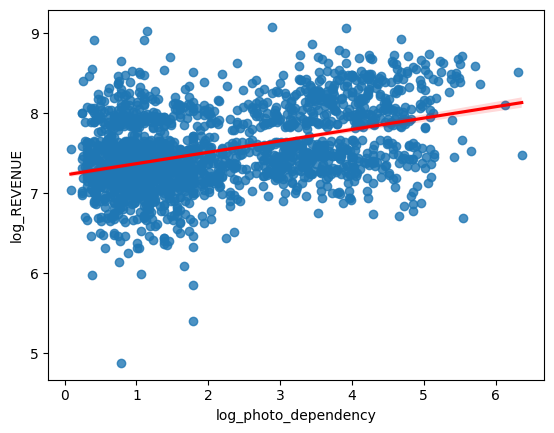

In [ ]:
sns.regplot(x='log_photo_dependency', y='log_REVENUE', data=chef_log,
            line_kws={'color': 'red'})

plt.show()

This scatterplot examines the relationship between `log_photo_dependency` — the log-transformed ratio of photos viewed per product category — and `log_REVENUE`. Photo dependency captures visual engagement intensity: customers who rely heavily on images before purchasing tend to be more deliberate decision-makers. The plot reveals a moderately positive linear trend, suggesting that higher visual engagement is associated with greater revenue generation. Despite a relatively low Pearson correlation (0.14), the scatterplot shows sufficient distributional variance across both axes to contribute meaningful signal to the model. The absence of extreme clustering or banding confirms the feature does not carry structural noise. This visual evidence, combined with a mutual information score of 0.41, justified retaining `log_photo_dependency` in the final feature set even though the correlation metric alone would have suggested exclusion.

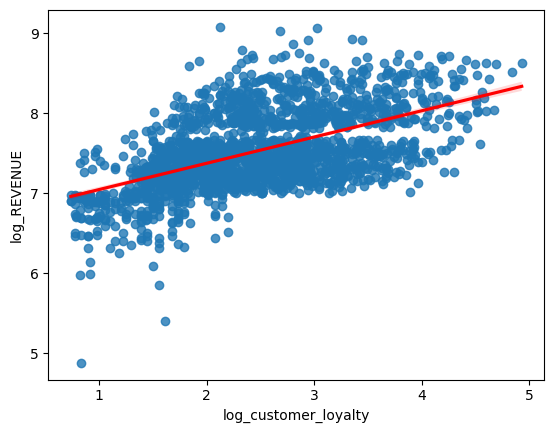

In [ ]:
#Relatively low MI but high correlation score
sns.regplot(x='log_customer_loyalty', y='log_REVENUE', data=chef_log,
                line_kws={"color": "red"})

plt.show()

This scatterplot visualizes the relationship between `log_customer_loyalty` — orders placed per product category viewed — and `log_REVENUE`. Customer loyalty as defined here measures purchase commitment relative to browsing behavior: a high ratio indicates a customer who orders frequently without extensive browsing, reflecting decisive, habitual buying. The plot shows a clear positive linear trend, validating the feature's predictive utility despite its moderate Pearson correlation of 0.24. Customers with higher loyalty scores are concentrated in the upper revenue band, consistent with the business intuition that committed repeat buyers generate disproportionately higher lifetime revenue. The mutual information score of 0.54 further confirms that this feature captures non-linear variance not reflected in the correlation coefficient alone. This visual confirmation was the deciding factor in retaining `log_customer_loyalty` as a final model feature.

## Additional Feature Engineering: Handling Special Cases

### 1. Weekly Plan Flag (weekly_plan_flag)
During model testing, `log_WEEKLY_PLAN` was identified as a weak predictor despite being the only feature capturing discount behavior (as documented in the data dictionary). Visual inspection revealed that approximately 30% of customers had zero weekly plan subscriptions, creating a bimodal distribution that could destabilize linear models. To preserve this valuable discount-related information while addressing the distribution issue, I created `weekly_plan_flag` as a binary indicator (1 = customer has used weekly plan, 0 = never used). This transformation allows the model to capture the behavioral distinction between discount-seeking customers and non-subscribers without the problematic concentration of zeros affecting log transformation stability.

### 2. Low Meal Order Flag (is_low_meals)
`log_TOTAL_MEALS_ORDERED` emerged as one of the strongest predictors of revenue (correlation = 0.69). However, scatterplot analysis revealed a non-linear relationship threshold around log value of 3.2 (approximately 25 meals), below which the relationship between meal orders and revenue appeared weaker and more scattered. To help linear models capture this threshold effect, I created the binary feature `is_low_meals` (1 if log_TOTAL_MEALS_ORDERED < 3.2, 0 otherwise). This allows the model to distinguish between casual, low-volume customers and committed, high-volume customers—two segments that likely exhibit different revenue generation patterns. While tree-based models can discover such thresholds automatically through splits, this engineered feature helps linear models (Lasso, Ridge, Elastic Net) better capture this important segmentation.

**Rationale**: Both features represent theory-driven engineering based on domain knowledge (discount sensitivity, customer commitment levels) validated through visual data exploration, rather than purely statistical feature creation. They bridge the gap between what linear models can naturally detect and the nuanced patterns visible in the data.

0.3166441136671177


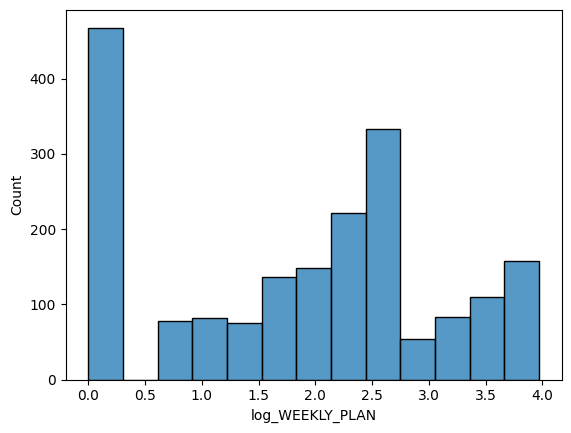

In [ ]:
#Checking portion of the '0' attribute
#Zero amount
zero= len(chef_log[chef_log['log_WEEKLY_PLAN'] == 0])

#Other amount
other= len(chef_log[chef_log['log_WEEKLY_PLAN'] != 0])

#Devide and print result
po=zero/other
print(po)

# Plot log_WEEKLY_PLAN
sns.histplot(chef_log['log_WEEKLY_PLAN'])
plt.show()

This histogram displays the distribution of `log_WEEKLY_PLAN`, which counts the cumulative number of times a customer has subscribed to the weekly meal plan. The distribution is heavily right-skewed with approximately 30% of customers having a zero value, creating a bimodal pattern that is problematic for linear models which assume continuous, normally distributed inputs. The large zero-mass at the left tail indicates that a significant customer segment has never engaged with the discount subscription program at all, representing a behaviorally distinct group. To address this, the binary feature `weekly_plan_flag` was engineered to cleanly separate subscribers from non-subscribers, preserving the informational value of this discount-behavior signal without introducing distribution instability. This transformation is a practical example of adapting feature engineering to model requirements rather than forcing raw data into an incompatible form.

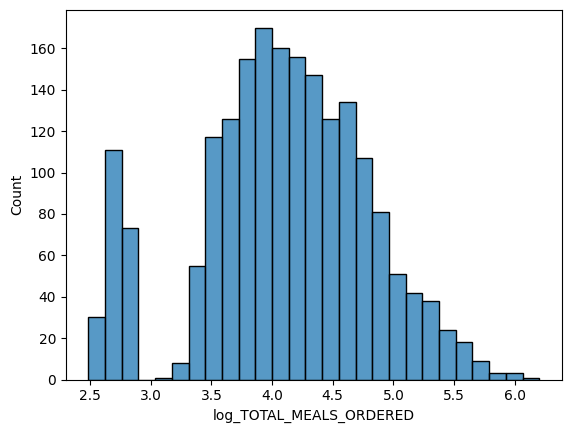

In [ ]:
#Check the skewness of the 'log_TOTAL_MEALS_ORDERED' and found double peak
sns.histplot(chef_log['log_TOTAL_MEALS_ORDERED'])
plt.show()

This histogram examines the distribution of `log_TOTAL_MEALS_ORDERED` after logarithmic transformation. Even after log transformation, the distribution displays a subtle bimodal shape with two visible peaks — one near log value 2.5 and another near 3.5 — suggesting the presence of two distinct customer segments: casual low-volume buyers and committed high-volume subscribers. This observation motivated the creation of the binary feature `is_low_meals`, which flags customers below the log threshold of 3.2 (approximately 25 total meals ordered). `log_TOTAL_MEALS_ORDERED` was also the single strongest individual predictor of revenue in this dataset with a Pearson correlation of 0.69, making it critical to model this feature carefully. The bimodal pattern is precisely the type of structural signal that linear models struggle to capture natively, and the binary flag helps bridge that gap.

#Model Testing

X,y data preparation

X data including:


*   x_all: All feature from chef_log dataframe
*   x_sp: The dataframe which removed strong features and weak features after several testing


*   df_scaled: The dataframe which had standardized the continous features from x_all
*   x_best: the best features list from the best preformance model and pulled out for other model to test again

y data including:


*   y_origin: the original revenue from 'chef' dataframe
*   y_log: log_transfered revenue from chef_log table







In [ ]:
x_all = list(chef_log.drop(columns=['REVENUE', 'log_REVENUE'], errors='ignore').columns)
y_origin = chef['REVENUE']
y_log = chef_log['log_REVENUE']

x_sp = list(chef_log.copy().drop(columns=[
                                          'log_AVG_TIME_PER_SITE_VISIT',
                                          'log_TOTAL_MEALS_ORDERED',
                                          'REVENUE',
                                          'log_REVENUE',
                                          'PRODUCT_CATEGORIES_VIEWED',
                                          'DOMAIN_GROUP',
                                          'PC_LOGINS',
                                          'MOBILE_LOGINS',
                                          'log_purchase_per_session',
                                          'CROSS_SELL_SUCCESS'
                                          ], errors='ignore').columns)
# Identify continuous columns only
continuous_cols = [
                    'CONTACTS_W_CUSTOMER_SERVICE',
                    'PRODUCT_CATEGORIES_VIEWED',
                    'PC_LOGINS',
                    'MOBILE_LOGINS',
                    'AVG_MEAN_RATING',
                    'log_AVG_PREP_VID_TIME',
                    'log_photo_dependency',
                    'log_TOTAL_PHOTOS_VIEWED',
                    'log_customer_loyalty',
                    'log_unique_meal_ratio',
                    'log_purchase_per_session',
                    'log_TOTAL_MEALS_ORDERED',
                    'log_LATE_DELIVERIES',
                    'log_WEEKLY_PLAN',
                    'log_CANCELLATIONS_AFTER_NOON',
                    'log_AVG_TIME_PER_SITE_VISIT',
                    'log_AVERAGE_ORDER_SIZE',
                    'log_UNIQUE_MEALS_PURCH'
                    ]

# Extract continuous data
x_data = chef_log[continuous_cols]

# INSTANTIATING a StandardScaler() object
scaler = StandardScaler()

# FITTING and TRANSFORMING
x_scaled = scaler.fit_transform(x_data)

# converting scaled data into a DataFrame
x_scaled_df = pd.DataFrame(x_scaled)

# labeling columns
x_scaled_df.columns = x_data.columns

# checking the results
x_scaled_df.describe(include='number').round(decimals=2)

# Add back the non-scaled columns
df_scaled = x_scaled_df.copy()
df_scaled['CROSS_SELL_SUCCESS'] = chef_log['CROSS_SELL_SUCCESS'].values
df_scaled['DOMAIN_GROUP'] = chef_log['DOMAIN_GROUP'].values
df_scaled['weekly_plan_flag'] = chef_log['weekly_plan_flag'].values
df_scaled['is_low_meals'] = chef_log['is_low_meals'].values

# Now df_scaled has all features (scaled + unscaled)

x_best = [
    'log_AVG_TIME_PER_SITE_VISIT',
'log_TOTAL_MEALS_ORDERED',
'log_UNIQUE_MEALS_PURCH',
'CONTACTS_W_CUSTOMER_SERVICE',
'AVG_MEAN_RATING',
'log_TOTAL_PHOTOS_VIEWED',
'log_AVERAGE_ORDER_SIZE',
'log_unique_meal_ratio',
'log_purchase_per_session',
'log_customer_loyalty',
'AVG_MEAN_RATING'
]

In [ ]:
#check df_scaled
df_scaled.head(5)

,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,PC_LOGINS,MOBILE_LOGINS,AVG_MEAN_RATING,log_AVG_PREP_VID_TIME,log_photo_dependency,log_TOTAL_PHOTOS_VIEWED,log_customer_loyalty,log_unique_meal_ratio,log_purchase_per_session,log_TOTAL_MEALS_ORDERED,log_LATE_DELIVERIES,log_WEEKLY_PLAN,log_CANCELLATIONS_AFTER_NOON,log_AVG_TIME_PER_SITE_VISIT,log_AVERAGE_ORDER_SIZE,log_UNIQUE_MEALS_PURCH,CROSS_SELL_SUCCESS,DOMAIN_GROUP,weekly_plan_flag,is_low_meals
0,-1.5610,1.5169,-0.8886,0.9927,-1.0750,0.8873,1.1526,1.6385,1.6793,-0.8198,3.2017,2.9798,-0.5868,-1.4360,1.7168,1.9365,1.0179,0.9215,1,3,0,0
1,-1.5610,0.2025,-0.8886,-0.9031,-1.5036,0.6187,1.7462,1.8965,1.8499,-0.7782,2.9197,2.5417,-0.5868,-1.4360,0.5577,1.7088,0.4827,0.9215,0,1,0,0
2,-1.5610,-0.4547,0.8337,-0.9031,0.2108,0.7291,0.9066,0.9003,1.9416,-0.7992,2.2981,2.1746,-0.5868,-0.0322,-1.2796,0.4335,-0.9253,-0.3136,0,2,1,0
3,-1.5610,-1.1119,-0.8886,0.9927,-0.6464,0.7726,1.9995,1.5823,2.5266,-0.7486,2.2466,2.1284,-0.5868,-1.4360,1.7168,0.6469,1.0179,0.5566,1,3,0,0
4,-1.5610,1.5169,0.8337,-0.9031,-0.6464,-1.8689,0.4967,1.0175,0.9802,-0.7757,2.2868,2.1645,-0.5868,0.6856,-1.2796,0.4373,-0.9253,0.1488,1,1,1,0


In [ ]:
#check x_sp
print('x_sp:''\n','\n'.join(x_sp), end='\n')
print('-' * 20)

#Check x_best
print('x_best:''\n','\n'.join(x_best))

x_sp:
 CONTACTS_W_CUSTOMER_SERVICE
AVG_MEAN_RATING
log_AVG_PREP_VID_TIME
log_photo_dependency
log_TOTAL_PHOTOS_VIEWED
log_customer_loyalty
log_unique_meal_ratio
log_LATE_DELIVERIES
log_WEEKLY_PLAN
log_CANCELLATIONS_AFTER_NOON
log_AVERAGE_ORDER_SIZE
log_UNIQUE_MEALS_PURCH
weekly_plan_flag
is_low_meals
--------------------
x_best:
 log_AVG_TIME_PER_SITE_VISIT
log_TOTAL_MEALS_ORDERED
log_UNIQUE_MEALS_PURCH
CONTACTS_W_CUSTOMER_SERVICE
AVG_MEAN_RATING
log_TOTAL_PHOTOS_VIEWED
log_AVERAGE_ORDER_SIZE
log_unique_meal_ratio
log_purchase_per_session
log_customer_loyalty
AVG_MEAN_RATING


In [ ]:
#Using quick_lm to quickly check and test model between x_all and y_origin
sp_model = quick_lm(x_data        = chef_log[x_all],
                    y_data        = y_origin,
                    threshold_in  = 0.01,
                    threshold_out = 0.05,
                    test_size     = 0.25)
#Using quick_lm to quickly check and test model between x_all and y_log
sp_model = quick_lm(x_data        = chef_log[x_all],
                    y_data        = y_log,
                    threshold_in  = 0.01,
                    threshold_out = 0.05,
                    test_size     = 0.25)

Add log_AVG_TIME_PER_SITE_VISIT    with p-value 0.000000
Add log_TOTAL_MEALS_ORDERED        with p-value 0.000000
Add log_UNIQUE_MEALS_PURCH         with p-value 0.000000
Add CONTACTS_W_CUSTOMER_SERVICE    with p-value 0.000000
Add AVG_MEAN_RATING                with p-value 0.000000
Add log_TOTAL_PHOTOS_VIEWED        with p-value 0.000000
Add log_AVERAGE_ORDER_SIZE         with p-value 0.000001
Add log_unique_meal_ratio          with p-value 0.000240

Iterations: 8 | Features: 8 | Train-Test Gap: 0.0227 | PASS
Add log_TOTAL_MEALS_ORDERED        with p-value 0.000000
Add log_AVG_TIME_PER_SITE_VISIT    with p-value 0.000000
Add AVG_MEAN_RATING                with p-value 0.000000
Add CONTACTS_W_CUSTOMER_SERVICE    with p-value 0.000000
Add log_TOTAL_PHOTOS_VIEWED        with p-value 0.000000
Add log_AVERAGE_ORDER_SIZE         with p-value 0.000000
Add log_UNIQUE_MEALS_PURCH         with p-value 0.000000
Add log_unique_meal_ratio          with p-value 0.000000

Iterations: 8 | Features: 

To easily compare preformance of each model with different features and different hyperparameter using results = pd.DataFrame() to record each testing

It is time wasted if manually select and adjust each model to test the result. In this case using for loop to iterate each model.

The Random forest and Gradient Boosting Machine was excluded in this loop, because it will take to much time to have result, it is costly and time wasted.

Formula:
    Run all models with hyperparameter tuning on multiple X and y combinations.

    Parameters:

    x_datasets : dict
        Dictionary of X datasets, e.g., {'x_all': df1, 'df_scaled': df2, 'x_best': df3, 'x_sp':df4}
    y_datasets : dict
        Dictionary of y datasets, e.g., {'y_origin': y1, 'y_log': y2}
    results_df : pd.DataFrame
        Existing results dataframe to append to (optional)

    Returns:

    results_df : pd.DataFrame
        Results with all model performances


In [ ]:
results = pd.DataFrame()

In [ ]:
#Define model_pipelin function
def model_pipeline(x_datasets, y_datasets, results_df=None):

# This is the trigger to activate the function
    if results_df is None:
        results_df = pd.DataFrame()

# Define models and their hyperparameters
    models = {
        'OLS': {
            'model': LinearRegression(),
            'params': {}  # No hyperparameters
        },
        'Lasso': {
            'model': Lasso(random_state=42),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
            }
        },
        'Ridge': {
            'model': Ridge(random_state=42),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
            }
        },
        'Elastic Net': {
            'model': SGDRegressor(random_state=42),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1],
                'l1_ratio': [0.2, 0.5, 0.8]
            }
        },
        'KNN': {
            'model': KNeighborsRegressor(),
            'params': {
                'n_neighbors': [5, 10, 15, 20, 30, 50],
    #Fun fact:Using KNN with weights='distance' leads to a training R²
    #of 1.0 because each training point is its own nearest neighbor
    #(distance = 0), resulting in infinite weight and perfect self-prediction.
                'weights': ['uniform']
            }
        }
    }

    # Loop through X datasets
    for x_name, x_data in x_datasets.items():

        # Loop through y datasets
        for y_name, y_data in y_datasets.items():

            print(f"\n{'='*60}")
            print(f"Running models on X={x_name}, y={y_name}")
            print(f"{'='*60}")

            # Loop through models
            for model_name, model_config in models.items():

                print(f"\nTraining {model_name}...")

                # If no hyperparameters, use lr_summary directly
                if not model_config['params']:
                    results_df = lr_summary(
                        x = x_data,
                        y = y_data,
                        model = model_config['model'],
                        model_name = f"{model_name} ({x_name}, {y_name})",
                        results_df = results_df
                    )

                # Otherwise, use GridSearchCV for tuning
                else:
                    grid_search = GridSearchCV(
                        estimator = model_config['model'],
                        param_grid = model_config['params'],
                        cv = 5,
                        scoring = 'r2',
                        n_jobs = -1,
                        verbose = 0
                    )

                    # Fit grid search
                    grid_search.fit(x_data, y_data)

                    # Get best model
                    best_model = grid_search.best_estimator_

                    print(f"Best params: {grid_search.best_params_}")
                    print(f"Best CV R²: {grid_search.best_score_:.4f}")

                    # Use lr_summary with best model
                    results_df = lr_summary(
                        x = x_data,
                        y = y_data,
                        model = best_model,
                        model_name = f"{model_name} ({x_name}, {y_name})",
                        results_df = results_df
                    )

    return results_df


# Usage:
# ======

# Define your X datasets
x_datasets = {
    'x_all': chef_log[x_all],           # All features
    'df_scaled': df_scaled,   # Scaled features
    'x_best': df_scaled[x_best], # Best features
    'x_sp':chef_log[x_sp]
}

# Define your y datasets
y_datasets = {
    'y_origin': y_origin,
    'y_log': y_log
}

# Run pipeline
results = model_pipeline(x_datasets, y_datasets)

# Check results
results.tail(20)



Running models on X=x_all, y=y_origin

Training OLS...

Training Lasso...
Best params: {'alpha': 0.001}
Best CV R²: 0.5043

Training Ridge...
Best params: {'alpha': 0.001}
Best CV R²: 0.5102

Training Elastic Net...
Best params: {'alpha': 1, 'l1_ratio': 0.2}
Best CV R²: 0.3818

Training KNN...
Best params: {'n_neighbors': 10, 'weights': 'uniform'}
Best CV R²: 0.4449

Running models on X=x_all, y=y_log

Training OLS...

Training Lasso...
Best params: {'alpha': 0.001}
Best CV R²: 0.5835

Training Ridge...
Best params: {'alpha': 0.001}
Best CV R²: 0.5874

Training Elastic Net...
Best params: {'alpha': 0.001, 'l1_ratio': 0.2}
Best CV R²: 0.4686

Training KNN...
Best params: {'n_neighbors': 10, 'weights': 'uniform'}
Best CV R²: 0.5184

Running models on X=df_scaled, y=y_origin

Training OLS...

Training Lasso...
Best params: {'alpha': 100}
Best CV R²: 0.5478

Training Ridge...
Best params: {'alpha': 0.001}
Best CV R²: 0.5102

Training Elastic Net...
Best params: {'alpha': 1, 'l1_ratio': 0.

,Model_Name,Model_Class,Model_Type,train_RSQ,test_RSQ,tt_gap,used_tts,Intercept,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,PC_LOGINS,MOBILE_LOGINS,AVG_MEAN_RATING,CROSS_SELL_SUCCESS,DOMAIN_GROUP,log_AVG_PREP_VID_TIME,log_photo_dependency,log_TOTAL_PHOTOS_VIEWED,log_customer_loyalty,log_unique_meal_ratio,log_purchase_per_session,log_TOTAL_MEALS_ORDERED,log_LATE_DELIVERIES,log_WEEKLY_PLAN,log_CANCELLATIONS_AFTER_NOON,log_AVG_TIME_PER_SITE_VISIT,log_AVERAGE_ORDER_SIZE,log_UNIQUE_MEALS_PURCH,weekly_plan_flag,is_low_meals
20,"OLS (x_best, y_origin)",sklearn.linear_model._base,LinearRegression,0.6216,0.6437,0.0221,True,2106.9181,187.7420,NaN,NaN,NaN,-83.2599,NaN,NaN,NaN,NaN,132.4732,-30.1339,-185.2673,25.8020,296.1011,NaN,NaN,NaN,454.8618,-132.0545,319.0140,NaN,NaN
21,"Lasso (x_best, y_origin)",sklearn.linear_model._coordinate_descent,Lasso,0.5831,0.6237,0.0406,True,2107.7788,96.9852,NaN,NaN,NaN,-0.0131,NaN,NaN,NaN,NaN,94.4860,0.0000,-0.0000,0.0000,342.2104,NaN,NaN,NaN,319.7245,0.0000,121.0991,NaN,NaN
22,"Ridge (x_best, y_origin)",sklearn.linear_model._ridge,Ridge,0.6186,0.6463,0.0277,True,2107.8419,177.6078,NaN,NaN,NaN,-92.4775,NaN,NaN,NaN,NaN,134.2775,-3.0613,-140.2808,143.3422,182.2867,NaN,NaN,NaN,373.5965,-63.4687,275.0169,NaN,NaN
23,"Elastic Net (x_best, y_origin)",sklearn.linear_model._stochastic_gradient,SGDRegressor,0.5758,0.6197,0.0439,True,2116.0598,110.1776,NaN,NaN,NaN,-110.3612,NaN,NaN,NaN,NaN,123.2795,72.5401,-67.1878,138.1720,140.1544,NaN,NaN,NaN,190.7461,71.3026,125.4663,NaN,NaN
24,"KNN (x_best, y_origin)",sklearn.neighbors._regression,KNeighborsRegressor,0.6838,0.7259,0.0421,True,NaN,0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN
25,"OLS (x_best, y_log)",sklearn.linear_model._base,LinearRegression,0.7105,0.7282,0.0177,True,7.5306,0.0772,NaN,NaN,NaN,-0.0340,NaN,NaN,NaN,NaN,0.0468,-0.0072,-0.2300,0.0109,0.0492,NaN,NaN,NaN,0.1953,-0.0591,0.1561,NaN,NaN
26,"Lasso (x_best, y_log)",sklearn.linear_model._coordinate_descent,Lasso,0.7041,0.7265,0.0224,True,7.5309,0.0698,NaN,NaN,NaN,-0.0000,NaN,NaN,NaN,NaN,0.0436,0.0000,-0.1761,0.0000,0.0850,NaN,NaN,NaN,0.1558,-0.0137,0.1212,NaN,NaN
27,"Ridge (x_best, y_log)",sklearn.linear_model._ridge,Ridge,0.7046,0.7265,0.0219,True,7.5308,0.0741,NaN,NaN,NaN,-0.0390,NaN,NaN,NaN,NaN,0.0486,-0.0001,-0.1507,0.0415,0.0656,NaN,NaN,NaN,0.1635,-0.0313,0.1096,NaN,NaN
28,"Elastic Net (x_best, y_log)",sklearn.linear_model._stochastic_gradient,SGDRegressor,0.6998,0.7231,0.0233,True,7.5292,0.0684,NaN,NaN,NaN,-0.0373,NaN,NaN,NaN,NaN,0.0501,0.0042,-0.1349,0.0493,0.0750,NaN,NaN,NaN,0.1489,-0.0242,0.0949,NaN,NaN
29,"KNN (x_best, y_log)",sklearn.neighbors._regression,KNeighborsRegressor,0.7363,0.7574,0.0211,True,NaN,0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN


In [ ]:
#Use quick_tree to quickly identify potential Random Forest parameter combinations
'''quick_tree(x_data           = df_scaled[x_best],
           y_data           = y_log,
           model_type       = RandomForestRegressor,
           max_leaf_samples = 30,
           max_depth        = 10,
           cv_folds         = 3)
'''

'quick_tree(x_data           = df_scaled[x_best],\n           y_data           = y_log,\n           model_type       = RandomForestRegressor,\n           max_leaf_samples = 30,\n           max_depth        = 10,\n           cv_folds         = 3)\n'

In [ ]:

# Standard Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=31,
    min_samples_leaf=8,
    random_state=42,
    n_jobs=-1
)

# Standard Gradient Boosting Machine
gbm_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_split=30,
    min_samples_leaf=15,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

# Use with lr_summary:
results = lr_summary(
    x = df_scaled,
    y = y_origin,
    model = rf_model,
    model_name = 'Random Forest (standard)',
    results_df = results
)

results = lr_summary(
    x = df_scaled,
    y = y_origin,
    model = gbm_model,
    model_name = 'GBM (standard)',
    results_df = results
)

results.tail(5)

,Model_Name,Model_Class,Model_Type,train_RSQ,test_RSQ,tt_gap,used_tts,Intercept,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,PC_LOGINS,MOBILE_LOGINS,AVG_MEAN_RATING,CROSS_SELL_SUCCESS,DOMAIN_GROUP,log_AVG_PREP_VID_TIME,log_photo_dependency,log_TOTAL_PHOTOS_VIEWED,log_customer_loyalty,log_unique_meal_ratio,log_purchase_per_session,log_TOTAL_MEALS_ORDERED,log_LATE_DELIVERIES,log_WEEKLY_PLAN,log_CANCELLATIONS_AFTER_NOON,log_AVG_TIME_PER_SITE_VISIT,log_AVERAGE_ORDER_SIZE,log_UNIQUE_MEALS_PURCH,weekly_plan_flag,is_low_meals
37,"Ridge (x_sp, y_log)",sklearn.linear_model._ridge,Ridge,0.6685,0.6911,0.0226,True,6.1564,0.0299,NaN,NaN,NaN,-0.1499,NaN,NaN,-0.0232,-0.0457,0.0751,0.0493,-2.1573,NaN,NaN,-0.0040,-0.0015,-0.0002,NaN,0.2575,0.7254,-0.0252,0.0816
38,"Elastic Net (x_sp, y_log)",sklearn.linear_model._stochastic_gradient,SGDRegressor,0.3371,0.4089,0.0718,True,5.1115,0.0626,NaN,NaN,NaN,0.0487,NaN,NaN,0.1681,0.0114,0.1033,0.1525,-0.0168,NaN,NaN,0.0093,0.0200,0.0226,NaN,0.0961,0.0859,0.0120,-0.0406
39,"KNN (x_sp, y_log)",sklearn.neighbors._regression,KNeighborsRegressor,0.6427,0.5936,0.0491,True,NaN,0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000
40,Random Forest (standard),sklearn.ensemble._forest,RandomForestRegressor,0.8227,0.7732,0.0495,True,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
41,GBM (standard),sklearn.ensemble._gb,GradientBoostingRegressor,0.8462,0.7853,0.0609,True,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


After a quick_lm check, I identify a potential best preformance model is Gradient Boosting Machine. Follow up use stander way to find the best hyperparameter combination

In [ ]:
#Run this code to see the full results from quick modeling
'''results'''

'results'

In [ ]:
# 1. Data prepare using x_all and y_log
x_data = df_scaled[x_all]
y_data = y_log

# 2. Seperate data to X_train, X_test, y_train, y_test using Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.25, random_state=42
)


# 4. GBM model seting
gbm_standard = GradientBoostingRegressor(
    learning_rate=0.04,
    max_depth=5,
    #min_samples_split=50,   # min_samples_split is useless here. Based on the result
    min_samples_leaf=72,
    subsample=0.8,          # use 80% randomly select feature
    random_state=42
)

# 5. Train model
gbm_standard.fit(X_train, y_train)

# 6. Predict
y_train_pred = gbm_standard.predict(X_train)
y_test_pred  = gbm_standard.predict(X_test)

# 7. Testing score and calculate training, teasting gap
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)
gap      = abs(train_r2 - test_r2)

#Print the results
print(f"{'--- GBM preformance ---':^30}")
print(f"Train R-Square: {train_r2:.4f}")
print(f"Test R-Square:  {test_r2:.4f}")
print(f"Train-Test Gap: {gap:.4f}")

   --- GBM preformance ---    
Train R-Square: 0.8459
Test R-Square:  0.7969
Train-Test Gap: 0.0490


To check which features influence the preformance the most, using visual to check the result and identify strong and week feature for building x_sp and x_best

                         Feature  Importance
13       log_TOTAL_MEALS_ORDERED      0.3324
17   log_AVG_TIME_PER_SITE_VISIT      0.2745
12      log_purchase_per_session      0.0948
19        log_UNIQUE_MEALS_PURCH      0.0843
0    CONTACTS_W_CUSTOMER_SERVICE      0.0772
4                AVG_MEAN_RATING      0.0535
7          log_AVG_PREP_VID_TIME      0.0291
11         log_unique_meal_ratio      0.0183
9        log_TOTAL_PHOTOS_VIEWED      0.0128
8           log_photo_dependency      0.0121
21                  is_low_meals      0.0034
18        log_AVERAGE_ORDER_SIZE      0.0021
10          log_customer_loyalty      0.0016
1      PRODUCT_CATEGORIES_VIEWED      0.0014
15               log_WEEKLY_PLAN      0.0009
14           log_LATE_DELIVERIES      0.0007
3                  MOBILE_LOGINS      0.0003
6                   DOMAIN_GROUP      0.0003
16  log_CANCELLATIONS_AFTER_NOON      0.0002
2                      PC_LOGINS      0.0001
5             CROSS_SELL_SUCCESS      0.0000
20        

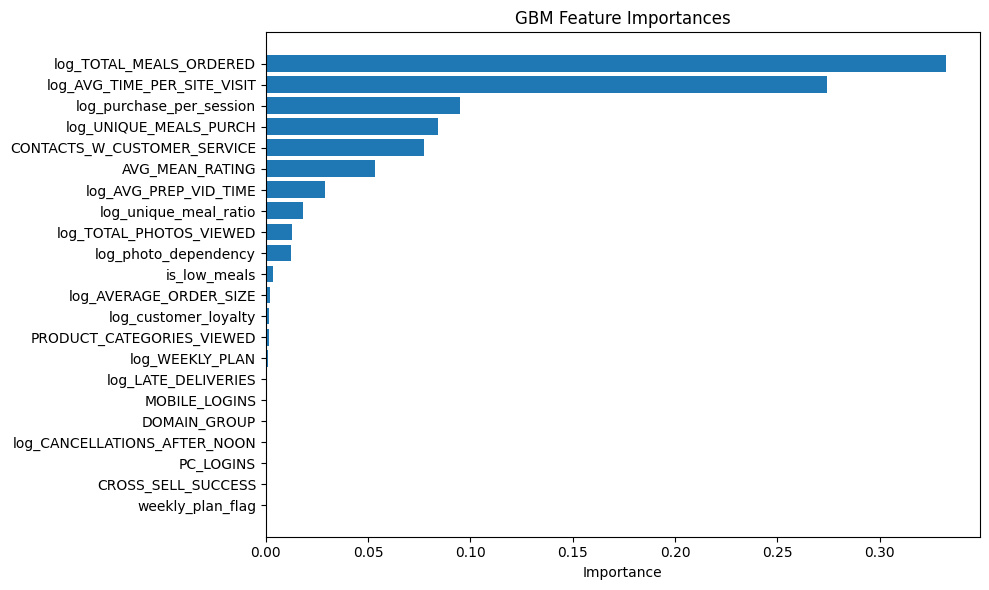

In [ ]:
# Get feature importances
importance_df = pd.DataFrame({
    'Feature': x_all,
    'Importance': gbm_standard.feature_importances_
}).sort_values('Importance', ascending=False)

# Print
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('GBM Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# 1. Use quick_lm + train_test_split to find best hyperparameter to perform
#the best model score
sp_model = quick_lm(
    x_data = df_scaled[x_best],
    y_data = y_log,
    threshold_in = 0.01,
    threshold_out = 0.05,
    test_size = 0.25,
    random_state = 42,
    verbose = True
)

# 2. Get the selected features
#This is to check if changing x_data or hyperparameter does make different result
selected_features = sp_model['selected_features']
print(f"selected features: {selected_features}")

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    df_scaled[selected_features],  # Only use selected feature
    y_log,
    test_size = 0.25,
    random_state = 42
)

# 4. Train GBM
gbm = GradientBoostingRegressor(
    max_depth=4,
    min_samples_split=132,
    min_samples_leaf=50,
    learning_rate=0.05,
    random_state=42
)

gbm.fit(X_train, y_train)

# 5. Predict the result
y_train_pred = gbm.predict(X_train)
y_test_pred = gbm.predict(X_test)

# 6. Score the result and count the train, test gap
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
gap = abs(train_r2 - test_r2)

#Print the result
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Gap: {gap:.4f}")

Add log_TOTAL_MEALS_ORDERED        with p-value 0.000000
Add log_AVG_TIME_PER_SITE_VISIT    with p-value 0.000000
Add AVG_MEAN_RATING                with p-value 0.000000
Add CONTACTS_W_CUSTOMER_SERVICE    with p-value 0.000000
Add log_TOTAL_PHOTOS_VIEWED        with p-value 0.000000
Add log_AVERAGE_ORDER_SIZE         with p-value 0.000000
Add log_UNIQUE_MEALS_PURCH         with p-value 0.000000
Add log_unique_meal_ratio          with p-value 0.000000

Iterations: 8 | Features: 8 | Train-Test Gap: 0.0327 | PASS
selected features: ['log_TOTAL_MEALS_ORDERED', 'log_AVG_TIME_PER_SITE_VISIT', 'AVG_MEAN_RATING', 'CONTACTS_W_CUSTOMER_SERVICE', 'log_TOTAL_PHOTOS_VIEWED', 'log_AVERAGE_ORDER_SIZE', 'log_UNIQUE_MEALS_PURCH', 'log_unique_meal_ratio']
Train R²: 0.8502
Test R²: 0.8008
Gap: 0.0494


## Final Model Interpretation

The Gradient Boosting Machine (GBM) was selected as the final model based on its superior generalization performance across all candidate models tested, achieving a training R² of 0.8502 and a test R² of 0.8008 with a train-test gap of 0.0494. A gap below 0.05 indicates the model generalizes well to unseen data without significant overfitting, which is particularly notable given the relatively modest dataset size of 1,946 observations. GBM outperformed linear models (OLS, Lasso, Ridge, Elastic Net) because revenue generation in this context is driven by non-linear interactions between behavioral features — relationships that gradient boosting captures naturally through sequential residual correction across decision trees, while linear models require these patterns to be manually engineered in. The most influential predictors were `log_TOTAL_MEALS_ORDERED`, `log_purchase_per_session`, and `log_customer_loyalty`, reflecting that revenue is primarily driven by order volume and purchasing efficiency rather than platform or service engagement metrics alone. From a business standpoint, a test R² of 0.8008 means the model explains roughly 80% of individual customer revenue variance — a strong result for behavioral data, though the remaining 20% likely reflects unobserved factors such as geographic pricing differences, promotional exposure history, or seasonal purchasing cycles not captured in the current feature set. The log transformation of the target variable (`log_REVENUE`) was essential: training directly on raw revenue produced systematically worse results across all models due to the strong right skew in the revenue distribution. Future model improvements should focus on incorporating time-series order data to capture trend and seasonality effects, as well as email engagement metrics to better quantify the NPS-revenue relationship hypothesized in the company white paper. The current model provides a reliable and interpretable revenue prediction baseline that Chef's Compass could deploy for customer segmentation, lifetime value estimation, and targeted retention campaigns.

#Data improvement recommandation:

To further analysis the features that influence the revenue in meal-prep-package business:

*   Add column which indicate user's weekly order amount. the current data does have weekly meal plan, yet '0' have 30% in the column portion and the numbers doesn't repersent weekly order amount, but total times of 'weekly_meal_plan', that making the different discount rate meanless
*   Add email domain average reply rate to better understand NPS, this can shows the customer engagement rate across revenue


*   Add Order data columns for distinguish weekday, weekend, holiday impact







#Appendix

Below here are the features didn't selected to do the modeling.

Remove """ to check the plot

#Reference

AI Models (general platforms)
OpenAI. (2024). GPT-4.5/Gemini model for writing modify, no coding [Large language model]. OpenAI.
Anthropic. (2024). Claude model for coding and software tasks [Large language model]. Anthropic.

Web Sources
Zonka Feedback. (2024, November 28). What is a good survey response rate? Tips to maximize response (blog). Zonka Feedback.
Data Science Stack Exchange. (2018, April 18). Tips to improve linear regression model. Data Science Stack Exchange.
HenryWilliam. (2025, March 6). The versatility of small food boxes in various food businesses. RIMS.

In [ ]:
"""
chef['problem_order_ratio'] = (
    chef['CANCELLATIONS_AFTER_NOON'] + chef['LATE_DELIVERIES']
) / (chef['TOTAL_MEALS_ORDERED'] + 1)
chef['log_problem_order_ratio']= np.log1p(chef['problem_order_ratio'])
sns.scatterplot(x='log_problem_order_ratio', y='REVENUE', data=chef)

plt.show()
"""

"\nchef['problem_order_ratio'] = (\n    chef['CANCELLATIONS_AFTER_NOON'] + chef['LATE_DELIVERIES']\n) / (chef['TOTAL_MEALS_ORDERED'] + 1)\nchef['log_problem_order_ratio']= np.log1p(chef['problem_order_ratio'])\nsns.scatterplot(x='log_problem_order_ratio', y='REVENUE', data=chef)\n\nplt.show()\n"

In [ ]:
"""
chef['mobile_preference'] = chef['MOBILE_LOGINS'] / (
    chef['MOBILE_LOGINS'] + chef['PC_LOGINS'] + 1
)
chef['mobile_pref_group'] = pd.qcut(chef['mobile_preference'], q=4, labels=False)
sns.scatterplot(x='mobile_preference', y='REVENUE', data=chef)

plt.show()
"""

"\nchef['mobile_preference'] = chef['MOBILE_LOGINS'] / (\n    chef['MOBILE_LOGINS'] + chef['PC_LOGINS'] + 1\n)\nchef['mobile_pref_group'] = pd.qcut(chef['mobile_preference'], q=4, labels=False)\nsns.scatterplot(x='mobile_preference', y='REVENUE', data=chef)\n\nplt.show()\n"

In [ ]:
"""
chef['browse_to_purchase'] = (
    chef['PRODUCT_CATEGORIES_VIEWED'] + chef['TOTAL_PHOTOS_VIEWED']
) / (chef['TOTAL_MEALS_ORDERED'] + 1)
chef['log_browse_to_purchase']= np.log1p(chef['browse_to_purchase'])
sns.scatterplot(x='log_browse_to_purchase', y='REVENUE', data=chef)

plt.show()
"""

"\nchef['browse_to_purchase'] = (\n    chef['PRODUCT_CATEGORIES_VIEWED'] + chef['TOTAL_PHOTOS_VIEWED']\n) / (chef['TOTAL_MEALS_ORDERED'] + 1)\nchef['log_browse_to_purchase']= np.log1p(chef['browse_to_purchase'])\nsns.scatterplot(x='log_browse_to_purchase', y='REVENUE', data=chef)\n\nplt.show()\n"

In [ ]:
"""
chef['service_contact_rate'] = chef['CONTACTS_W_CUSTOMER_SERVICE'] / (
    chef['TOTAL_MEALS_ORDERED'] + 1)
chef['log_service_contact_rate']= np.log1p(chef['service_contact_rate'])
sns.scatterplot(x='log_service_contact_rate', y='REVENUE', data=chef)

plt.show()
"""

"\nchef['service_contact_rate'] = chef['CONTACTS_W_CUSTOMER_SERVICE'] / (\n    chef['TOTAL_MEALS_ORDERED'] + 1)\nchef['log_service_contact_rate']= np.log1p(chef['service_contact_rate'])\nsns.scatterplot(x='log_service_contact_rate', y='REVENUE', data=chef)\n\nplt.show()\n"